In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import torchvision
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

## PART 1: Raytracer

In [2]:
RED=np.array([1.0, 0.0, 0.0])
GREEN=np.array([0.0, 1.0, 0.0])
BLUE=np.array([0.0, 0.0, 1.0])
WHITE=np.array([1.0, 1.0, 1.0])

In [3]:
class Sphere():
    def __init__(self, center, color, r=None):
        self.c = np.asarray(center)
        self.color = np.asarray(color)
        self.r = r

    # adapted from jamesbowman/raytrace
    def intersect(self, origin, direction):
        if self.r is None:
            f = 1.0 - origin[2]
            z = self.c[2] - origin[2]
            r = 0.05 * z / f
        else:
            r = self.r
        
        b = 2 * np.dot(direction, (origin - self.c))
        c1 = self.c @ self.c
        c2 = origin @ origin
        c3 = self.c @ origin
        c4 = r * r
        c = c1 + c2 - 2 * c3 - c4
        disc = b * b - 4 * c
        sq = np.sqrt(np.maximum(0, disc))
        h0 = (-b - sq) / 2
        h1 = (-b + sq) / 2
        h = np.where((h0 > 0) & (h0 < h1), h0, h1)
        pred = (disc > 0) & (h > 0)
        return np.where(pred, h, np.inf)

In [4]:
## Rendering
def raytrace(origin, direction, scene, bw=False):
    distances = np.array([s.intersect(origin, direction) for s in scene])
    nearest = np.min(distances, axis=0)

    if bw: color = np.zeros(direction.shape[0])
    else:  color = np.zeros((direction.shape[0], 3))  # R=0 G=0 B=0
        
    for (s, d) in zip(scene, distances):
        hit = (nearest != np.inf) & (d == nearest)
        color[hit] = 1 if bw else s.color
    return color

def render(scene, camera, w=128, h=128, step=0.1, frames=4, f=1.0, bw=False):
    r = float(w) / h
    screen = (-1, 1 / r + .25, 1, -1 / r + .25)
    x = np.tile(np.linspace(screen[0], screen[2], w), h)
    y = np.repeat(np.linspace(screen[1], screen[3], h), w)

    q = np.column_stack((x, y, np.full_like(x, f)))

    if bw: images = np.empty((frames, h, w))
    else:  images = np.empty((frames, h, w, 3))
    c = np.copy(camera)

    for i in range(frames):
        direction = q / np.linalg.norm(q, axis=1, keepdims=True)
        if bw:
            images[i] = raytrace(c, direction, scene, bw=bw).reshape(h, w)
        else:
            images[i] = raytrace(c, direction, scene, bw=bw).reshape(h, w, 3)
        c += np.array([0.0, 0.0, step])

    return images

def display(images):
    n_frames = images.shape[0]
    fig, axes = plt.subplots(
        1, n_frames,
        figsize=(3 * n_frames, 3.2),
        facecolor="#ffffff"
    )
    fig.subplots_adjust(wspace=0.04)
    
    if n_frames == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    plt.show()

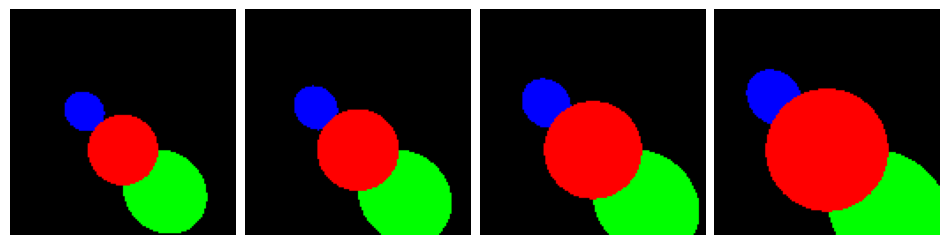

In [5]:
scene = [Sphere([0.0, 0.0, 2.0],  RED,   0.6),
         Sphere([1.0, -1.0, 3.0], GREEN, 1.0),
         Sphere([-1.0, 1.0, 3.0], BLUE,  0.5)]
camera = np.array([0.0, 0.0, 0.0])

images = render(scene, camera, step=0.25)
display(images)

## PART 2: Dataset

In [6]:
def dot_scene(distance, count=200, spread_xy=1.0, depth_jitter=1.0,
                   min_radius=0.01, max_radius=0.03):
    scene = []

    for _ in range(count):
        x = random.uniform(-spread_xy, spread_xy)
        y = random.uniform(-spread_xy, spread_xy)
        z = random.uniform(distance - depth_jitter, distance + depth_jitter)
        r = min_radius + (max_radius - min_radius) * (random.random() ** 2)
        scene.append(Sphere([x, y, z], WHITE, None))

    return scene

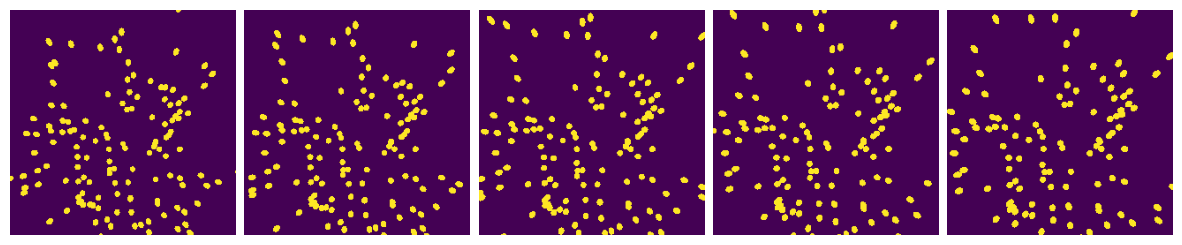

In [7]:
## Near scene
scene = dot_scene(0.0)
camera = np.array([0.0, 0.0, -1.0])

images = render(scene, camera, w=256, h=256, step=0.05, frames=5, bw=True)
display(images)

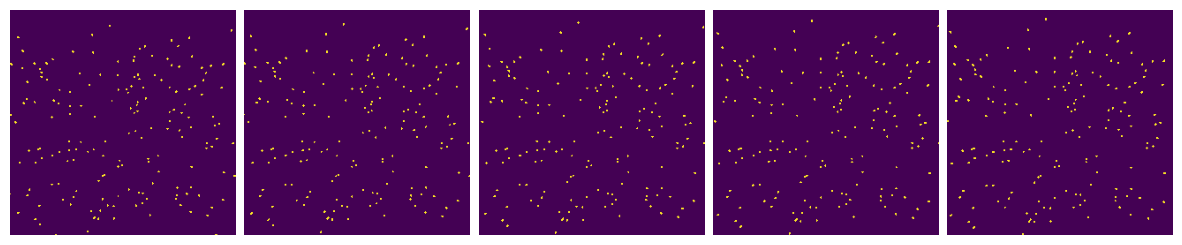

In [8]:
## Far scene
scene = dot_scene(0.0, spread_xy=5.0)
camera = np.array([0.0, 0.0, -5.0])

images = render(scene, camera, 256, 256, step=0.05, frames=5, bw=True)
display(images)

In [9]:
class SceneDataset(Dataset):
    def __init__(self, size):
        self.type = np.random.choice([0, 1], size=size)

    def __len__(self):
        return len(self.type)

    def __getitem__(self, idx):
        t = self.type[idx] 
        scene = dot_scene(0.0, spread_xy=5.0)
        if t == 0:
            camera = np.array([0.0, 0.0, -5.0])
        else:
            camera = np.array([0.0, 0.0, -1.0])
        
        out = render(scene, camera, 256, 256, step=0.05, frames=4, bw=True)
        return torch.Tensor(out), t

In [ ]:
# force exact balance in dataset for more interpretable results
class BalancedSceneDataset(Dataset):
    def __init__(self, size):
        half = size // 2
        labels = np.array([0] * half + [1] * (size - half))
        np.random.shuffle(labels)
        self.type = labels

    def __len__(self):
        return len(self.type)

    def __getitem__(self, idx):
        t = self.type[idx]
        scene = dot_scene(0.0, spread_xy=5.0)

        if t == 0:
            camera = np.array([0.0, 0.0, -5.0])   # far
        else:
            camera = np.array([0.0, 0.0, -1.0])   # near

        out = render(scene, camera, 256, 256, step=0.05, frames=4, bw=True)
        return torch.Tensor(out), t

## PART 3: Waves

In [40]:
def make_coordinate_grid(grid_size):
    coords = np.arange(grid_size)
    return np.meshgrid(coords, coords, indexing="xy")

def normalize_frame(frame):
    frame = np.clip(frame, 0.0, None)
    max_val = frame.max()
    if max_val > 0:
        frame = frame / max_val
    return frame

def expanding_ring_sequence(
    grid_size=256,
    n_frames=4,
    noise_std=0.05,
    noise_mean=0.0,
    dr=None,
    clip=True
):
    if dr is None:
        dr = np.random.beta(1.5, 3.5) / 4
    
    xx, yy = make_coordinate_grid(grid_size)

    center = (grid_size - 1) / 2
    cx = center + np.random.uniform(-grid_size / 2, grid_size / 2)
    cy = center + np.random.uniform(-grid_size / 2, grid_size / 2)

    rr = np.hypot(xx - cx, yy - cy)
    r0 = np.random.uniform(grid_size / 12, grid_size / 4)
    width = np.random.uniform(grid_size / 12, grid_size / 10)

    rt = r0 + dr * grid_size * np.arange(n_frames)[:, None, None]
    frames = np.exp(-((rr - rt) ** 2) / (2 * width**2))

    frames = np.stack([normalize_frame(frame) for frame in frames], axis=0)

    noise = np.random.normal(loc=noise_mean, scale=noise_std, size=frames.shape)
    frames = frames + noise

    if clip:
        frames = np.clip(frames, 0.0, 1.0)

    return frames

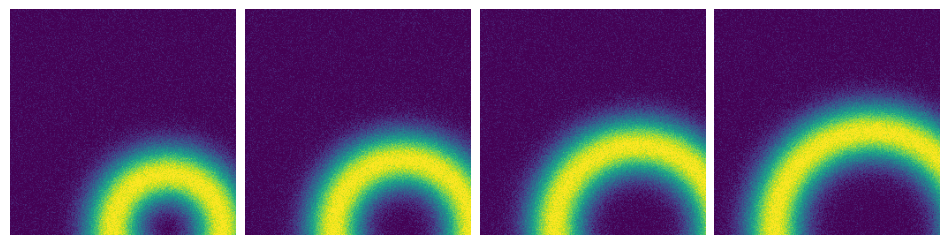

In [11]:
display(expanding_ring_sequence())

In [12]:
class RetinalWaveDataset(Dataset):
    def __init__(self, size):
        self.velocities = np.random.beta(1.5, 3.5, size=size)

    def __len__(self):
        return len(self.velocities)

    def __getitem__(self, idx):
        dr = self.velocities[idx]
        # generate two retinal waves of the same velocity
        return (torch.Tensor(expanding_ring_sequence(dr=dr)),
                torch.Tensor(expanding_ring_sequence(dr=dr)))

In [ ]:
# noise dataset for unrelated pretraining
class NoiseDataset(Dataset):
    def __init__(self, size, grid_size=256, n_frames=4):
        self.size = size
        self.grid_size = grid_size
        self.n_frames = n_frames

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # two random noise movies
        x1 = np.random.rand(self.n_frames, self.grid_size, self.grid_size).astype(np.float32)
        x2 = np.random.rand(self.n_frames, self.grid_size, self.grid_size).astype(np.float32)
        return torch.Tensor(x1), torch.Tensor(x2)

## PART 4: Pre-training

In [42]:
SIMCLR_EPOCHS = 10
SIMCLR_BATCH_SIZE = 64
SIMCLR_LR = 1e-3
SIMCLR_TEMPERATURE = 0.5
SIMCLR_LATENT = 32

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device {device}")

Using device mps


### Model Definition

A lightly modified ResNet18.

In [43]:
from torchvision.models import resnet18

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()

        # no pretraining
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(
            in_channels=4,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )

        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # -> [B, 512, 1, 1]
        self.head = nn.Linear(512, latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)         # [B, 512, 1, 1]
        x = torch.flatten(x, 1)      # [B, 512]
        z = self.head(x)             # [B, latent_dim]
        return z

### Loss function

In [17]:
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent (Normalized Temperature-scaled Cross-Entropy) loss.

    Args:
        z1: (N, D) projected representations of first augmented views
        z2: (N, D) projected representations of second augmented views
        temperature: temperature scaling parameter tau

    Returns:
        Scalar loss (mean over all 2N positive pairs)
    """
    N = z1.shape[0]

    z1 = F.normalize(z1)
    z2 = F.normalize(z2)
    z = torch.concatenate([z1, z2], dim=0)

    sim = torch.div(z @ z.T, temperature)
    sim.fill_diagonal_(float("-inf"))

    sums = torch.logsumexp(sim, dim=0)
    
    upair = torch.diagonal(sim, offset=N)
    lpair = torch.diagonal(sim, offset=-N)
    loss = torch.cat([upair, lpair]) - sums
    
    return -torch.mean(loss)

### Training objective

In [18]:
def train_simclr(encoder, train_loader, epochs, lr, temperature, device):
    """
    Train SimCLR: encoder + projection head with NT-Xent loss.

    Args:
        encoder: SimCLREncoder instance
        proj_head: ProjectionHead instance
        train_loader: DataLoader yielding ((view1, view2), labels)
        epochs: number of training epochs
        lr: learning rate
        temperature: NT-Xent temperature
        device: torch device

    Returns:
        List of average loss per epoch
    """
    params = list(encoder.parameters())
    optimizer = optim.Adam(params, lr=lr)
    loss_history = []

    encoder.train()

    for epoch in range(epochs):
        total_loss = 0.0
        num_batches = 0

        for x1, x2 in train_loader:
            x1 = x1.to(device)
            x2 = x2.to(device)

            z1, z2 = encoder(x1), encoder(x2)

            loss = nt_xent_loss(z1, z2, temperature=temperature)

            optimizer.zero_grad()
            loss.backward()    
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}")

    return loss_history

In [19]:
torch.manual_seed(181)

train = RetinalWaveDataset(size=512)
loader = DataLoader(train, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)
encoder = Encoder(SIMCLR_LATENT).to(device)

print("Retinal wave pre-training.")
losses = train_simclr(
    encoder, loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    temperature=SIMCLR_TEMPERATURE, device=device
)


Retinal wave pre-training.
  Epoch  1/10  loss=3.9798
  Epoch  2/10  loss=3.6759
  Epoch  3/10  loss=3.5664
  Epoch  4/10  loss=3.5288
  Epoch  5/10  loss=3.4983
  Epoch  6/10  loss=3.4760
  Epoch  7/10  loss=3.4777
  Epoch  8/10  loss=3.4514
  Epoch  9/10  loss=3.4022
  Epoch 10/10  loss=3.3794


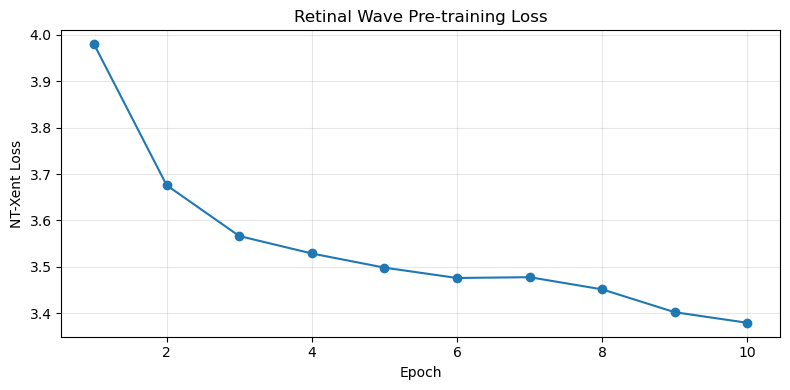

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("Retinal Wave Pre-training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PART 5: Evaluation

In [21]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(SIMCLR_LATENT, 1)

    def forward(self, x):
        return self.linear(x)

In [119]:
def train_classifier(encoder, classifier, loader, epochs, lr, device):
    params = list(classifier.parameters())
    optimizer = optim.Adam(params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    loss_history = []

    encoder.eval()
    classifier.train()

    for epoch in range(epochs):
        total_loss = 0.0
        num_batches = 0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            z = encoder(x)

            logits = classifier(z)
            loss = criterion(logits, y.float().unsqueeze(1)) 

            optimizer.zero_grad()
            loss.backward()    
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}")

    return loss_history

In [120]:
torch.manual_seed(181)

train = SceneDataset(size=512)
loader = DataLoader(train, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)
classifier = Classifier().to(device)

# uses the encoder from earlier
print("Pre-trained classifier.")
losses = train_classifier(
    encoder, classifier, loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    device=device
)

Pre-trained classifier.
  Epoch  1/10  loss=0.7607
  Epoch  2/10  loss=0.7360
  Epoch  3/10  loss=0.7117
  Epoch  4/10  loss=0.6919
  Epoch  5/10  loss=0.6738
  Epoch  6/10  loss=0.6579
  Epoch  7/10  loss=0.6432
  Epoch  8/10  loss=0.6254
  Epoch  9/10  loss=0.6083
  Epoch 10/10  loss=0.5941


In [ ]:
# accuracy helper for evaluation
def evaluate_classifier(encoder, classifier, loader, device):
    encoder.eval()
    classifier.eval()

    total = 0
    correct = 0
    total_loss = 0.0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().unsqueeze(1)

            z = encoder(x)
            logits = classifier(z)
            loss = criterion(logits, y)

            preds = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds.squeeze(1) == y.squeeze(1).long()).sum().item()
            total += y.size(0)
            total_loss += loss.item() * y.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

In [ ]:
# keeps track of training and validation accuracy too
def train_classifier_with_metrics(encoder, classifier, train_loader, epochs, lr, device, val_loader=None):
    params = list(classifier.parameters())
    optimizer = optim.Adam(params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    loss_history = []
    train_acc_history = []
    val_acc_history = []

    encoder.eval()
    classifier.train()

    for epoch in range(epochs):
        total_loss = 0.0
        total = 0
        correct = 0
        num_batches = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).float().unsqueeze(1)

            with torch.no_grad():
                z = encoder(x)

            logits = classifier(z)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

            preds = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds.squeeze(1) == y.squeeze(1).long()).sum().item()
            total += y.size(0)

        avg_loss = total_loss / num_batches
        train_acc = correct / total

        loss_history.append(avg_loss)
        train_acc_history.append(train_acc)

        if val_loader is not None:
            val_loss, val_acc = evaluate_classifier(encoder, classifier, val_loader, device)
            val_acc_history.append(val_acc)
            print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")
        else:
            print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}  train_acc={train_acc:.3f}")

    return {
        "loss": loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
    }

In [ ]:
# end-to-end supervised learning
def train_end_to_end(encoder, classifier, train_loader, epochs, lr, device, val_loader=None):
    params = list(encoder.parameters()) + list(classifier.parameters())
    optimizer = optim.Adam(params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):
        encoder.train()
        classifier.train()

        total_loss = 0.0
        total = 0
        correct = 0
        num_batches = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).float().unsqueeze(1)

            z = encoder(x)
            logits = classifier(z)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

            preds = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds.squeeze(1) == y.squeeze(1).long()).sum().item()
            total += y.size(0)

        avg_loss = total_loss / num_batches
        train_acc = correct / total

        loss_history.append(avg_loss)
        train_acc_history.append(train_acc)

        if val_loader is not None:
            val_loss, val_acc = evaluate_classifier(encoder, classifier, val_loader, device)
            val_acc_history.append(val_acc)
            print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")
        else:
            print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}  train_acc={train_acc:.3f}")

    return {
        "loss": loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
    }

In [44]:
torch.manual_seed(181)

train_scene = BalancedSceneDataset(size=512)
val_scene = BalancedSceneDataset(size=128)

train_loader = DataLoader(train_scene, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_scene, batch_size=SIMCLR_BATCH_SIZE, shuffle=False)

In [45]:
# retinal-wave pretrained encoder + frozen linear classifier
torch.manual_seed(181)

wave_train = RetinalWaveDataset(size=512)
wave_loader = DataLoader(wave_train, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)

wave_encoder = Encoder(SIMCLR_LATENT).to(device)
print("Retinal wave pre-training.")
wave_pretrain_losses = train_simclr(
    wave_encoder, wave_loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    temperature=SIMCLR_TEMPERATURE, device=device
)

wave_classifier = Classifier().to(device)
print("Wave-pretrained encoder + frozen linear classifier.")
wave_probe_hist = train_classifier_with_metrics(
    wave_encoder, wave_classifier, train_loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    device=device, val_loader=val_loader
)

Retinal wave pre-training.
  Epoch  1/10  loss=3.9826
  Epoch  2/10  loss=3.6559
  Epoch  3/10  loss=3.5509
  Epoch  4/10  loss=3.5142
  Epoch  5/10  loss=3.5073
  Epoch  6/10  loss=3.4920
  Epoch  7/10  loss=3.4802
  Epoch  8/10  loss=3.4246
  Epoch  9/10  loss=3.3918
  Epoch 10/10  loss=3.4133
Wave-pretrained encoder + frozen linear classifier.
  Epoch  1/10  loss=0.4203  train_acc=0.943  val_acc=0.914
  Epoch  2/10  loss=0.3766  train_acc=0.922  val_acc=0.977
  Epoch  3/10  loss=0.3438  train_acc=0.943  val_acc=0.969
  Epoch  4/10  loss=0.3086  train_acc=0.971  val_acc=0.992
  Epoch  5/10  loss=0.2873  train_acc=0.980  val_acc=0.977
  Epoch  6/10  loss=0.2708  train_acc=0.973  val_acc=0.969
  Epoch  7/10  loss=0.2576  train_acc=0.984  val_acc=1.000
  Epoch  8/10  loss=0.2446  train_acc=0.986  val_acc=0.992
  Epoch  9/10  loss=0.2263  train_acc=0.988  val_acc=0.984
  Epoch 10/10  loss=0.2107  train_acc=0.994  val_acc=0.984


In [46]:
# no pretraining baseline -- random encoder + frozen linear classifier
torch.manual_seed(181)

random_encoder = Encoder(SIMCLR_LATENT).to(device)
random_classifier = Classifier().to(device)

print("Random encoder + frozen linear classifier.")
random_probe_hist = train_classifier_with_metrics(
    random_encoder, random_classifier, train_loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    device=device, val_loader=val_loader
)

Random encoder + frozen linear classifier.
  Epoch  1/10  loss=0.6636  train_acc=0.500  val_acc=0.500
  Epoch  2/10  loss=0.6579  train_acc=0.500  val_acc=0.500
  Epoch  3/10  loss=0.6531  train_acc=0.500  val_acc=0.500
  Epoch  4/10  loss=0.6488  train_acc=0.500  val_acc=0.500
  Epoch  5/10  loss=0.6445  train_acc=0.500  val_acc=0.500
  Epoch  6/10  loss=0.6404  train_acc=0.500  val_acc=0.500
  Epoch  7/10  loss=0.6368  train_acc=0.500  val_acc=0.500
  Epoch  8/10  loss=0.6338  train_acc=0.500  val_acc=0.500
  Epoch  9/10  loss=0.6300  train_acc=0.500  val_acc=0.500
  Epoch 10/10  loss=0.6276  train_acc=0.500  val_acc=0.508


In [47]:
# no pretraining baseline -- full supervised training from scratch
torch.manual_seed(181)

scratch_encoder = Encoder(SIMCLR_LATENT).to(device)
scratch_classifier = Classifier().to(device)

print("Train encoder + classifier from scratch.")
scratch_hist = train_end_to_end(
    scratch_encoder, scratch_classifier, train_loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    device=device, val_loader=val_loader
)

Train encoder + classifier from scratch.
  Epoch  1/10  loss=0.1032  train_acc=0.932  val_acc=0.500
  Epoch  2/10  loss=0.0002  train_acc=1.000  val_acc=0.500
  Epoch  3/10  loss=0.0000  train_acc=1.000  val_acc=0.500
  Epoch  4/10  loss=0.0000  train_acc=1.000  val_acc=0.500
  Epoch  5/10  loss=0.0000  train_acc=1.000  val_acc=1.000
  Epoch  6/10  loss=0.0000  train_acc=1.000  val_acc=1.000
  Epoch  7/10  loss=0.0000  train_acc=1.000  val_acc=1.000
  Epoch  8/10  loss=0.0000  train_acc=1.000  val_acc=1.000
  Epoch  9/10  loss=0.0000  train_acc=1.000  val_acc=1.000
  Epoch 10/10  loss=0.0000  train_acc=1.000  val_acc=1.000


In [48]:
# noise pretraining + frozen classifier
torch.manual_seed(181)

noise_train = NoiseDataset(size=512, grid_size=256, n_frames=4)
noise_loader = DataLoader(noise_train, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)

noise_encoder = Encoder(SIMCLR_LATENT).to(device)
print("Noise pre-training.")
noise_pretrain_losses = train_simclr(
    noise_encoder, noise_loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    temperature=SIMCLR_TEMPERATURE, device=device
)

noise_classifier = Classifier().to(device)
print("Noise-pretrained encoder + frozen linear classifier.")
noise_probe_hist = train_classifier_with_metrics(
    noise_encoder, noise_classifier, train_loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    device=device, val_loader=val_loader
)

Noise pre-training.
  Epoch  1/10  loss=4.8455
  Epoch  2/10  loss=4.8447
  Epoch  3/10  loss=4.8450
  Epoch  4/10  loss=4.8454
  Epoch  5/10  loss=4.8440
  Epoch  6/10  loss=4.8435
  Epoch  7/10  loss=4.8448
  Epoch  8/10  loss=4.8446
  Epoch  9/10  loss=4.8441
  Epoch 10/10  loss=4.8439
Noise-pretrained encoder + frozen linear classifier.
  Epoch  1/10  loss=1.8987  train_acc=0.500  val_acc=0.500
  Epoch  2/10  loss=1.0854  train_acc=0.500  val_acc=0.500
  Epoch  3/10  loss=0.7261  train_acc=0.477  val_acc=0.500
  Epoch  4/10  loss=0.7780  train_acc=0.498  val_acc=0.500
  Epoch  5/10  loss=0.7334  train_acc=0.449  val_acc=0.500
  Epoch  6/10  loss=0.7113  train_acc=0.500  val_acc=0.500
  Epoch  7/10  loss=0.7134  train_acc=0.500  val_acc=0.500
  Epoch  8/10  loss=0.7066  train_acc=0.498  val_acc=0.500
  Epoch  9/10  loss=0.7034  train_acc=0.484  val_acc=0.500
  Epoch 10/10  loss=0.7007  train_acc=0.502  val_acc=0.500


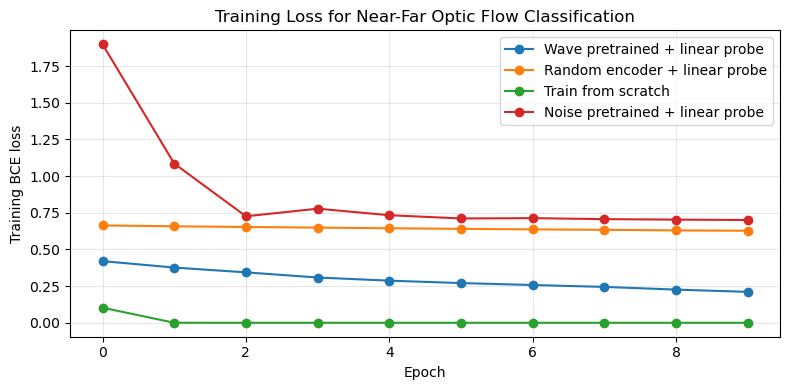

In [64]:
# compare downstream losses

plt.figure(figsize=(8, 4))
plt.plot(wave_probe_hist["loss"], marker="o", label="Wave pretrained + linear probe")
plt.plot(random_probe_hist["loss"], marker="o", label="Random encoder + linear probe")
plt.plot(scratch_hist["loss"], marker="o", label="Train from scratch")
plt.plot(noise_probe_hist["loss"], marker="o", label="Noise pretrained + linear probe")
plt.xlabel("Epoch")
plt.ylabel("Training BCE loss")
plt.title("Training Loss for Near-Far Optic Flow Classification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

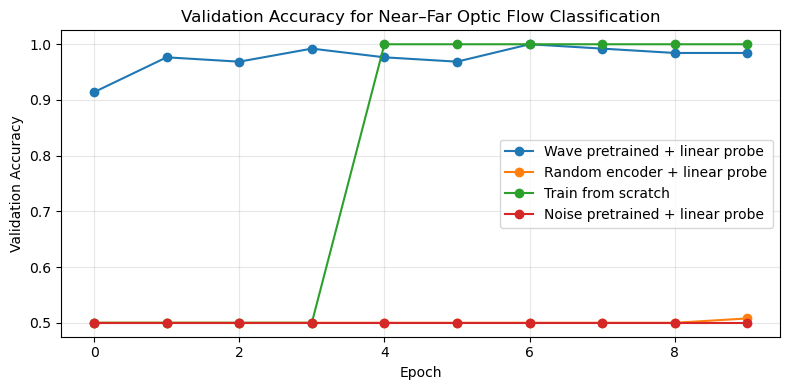

In [68]:
# compare validation accuracy

plt.figure(figsize=(8, 4))
plt.plot(wave_probe_hist["val_acc"], marker="o", label="Wave pretrained + linear probe")
plt.plot(random_probe_hist["val_acc"], marker="o", label="Random encoder + linear probe")
plt.plot(scratch_hist["val_acc"], marker="o", label="Train from scratch")
plt.plot(noise_probe_hist["val_acc"], marker="o", label="Noise pretrained + linear probe")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Near–Far Optic Flow Classification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

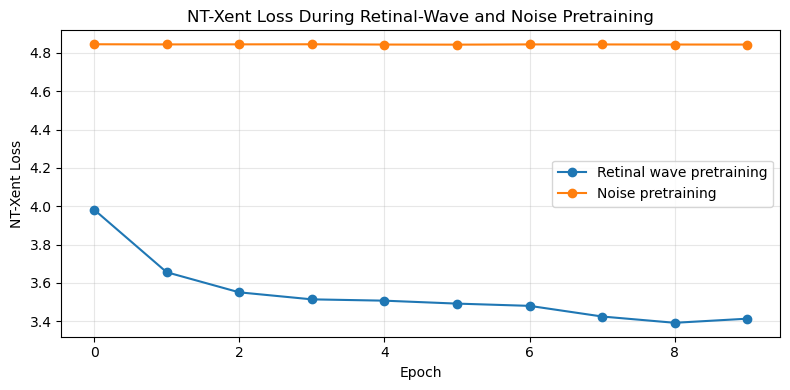

In [69]:
# compare pretraining losses

plt.figure(figsize=(8, 4))
plt.plot(wave_pretrain_losses, marker="o", label="Retinal wave pretraining")
plt.plot(noise_pretrain_losses, marker="o", label="Noise pretraining")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("NT-Xent Loss During Retinal-Wave and Noise Pretraining")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Prediction Inspections

In [52]:
train_scene = BalancedSceneDataset(size=512)
val_scene = BalancedSceneDataset(size=128)

print("Train label counts:", np.bincount(train_scene.type))
print("Val label counts:", np.bincount(val_scene.type))

print("Train proportions:", np.bincount(train_scene.type) / len(train_scene))
print("Val proportions:", np.bincount(val_scene.type) / len(val_scene))

Train label counts: [256 256]
Val label counts: [64 64]
Train proportions: [0.5 0.5]
Val proportions: [0.5 0.5]


In [53]:
def inspect_predictions(encoder, classifier, loader, device):
    encoder.eval()
    classifier.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = classifier(encoder(x))
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy().reshape(-1)

            all_preds.append(preds)
            all_targets.append(y.numpy().reshape(-1))

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    print("Predicted label counts:", np.bincount(all_preds, minlength=2))
    print("True label counts:     ", np.bincount(all_targets, minlength=2))
    print("Prediction proportions:", np.bincount(all_preds, minlength=2) / len(all_preds))
    print("Target proportions:    ", np.bincount(all_targets, minlength=2) / len(all_targets))

In [54]:
inspect_predictions(random_encoder, random_classifier, train_loader, device)
inspect_predictions(random_encoder, random_classifier, val_loader, device)

Predicted label counts: [512   0]
True label counts:      [256 256]
Prediction proportions: [1. 0.]
Target proportions:     [0.5 0.5]
Predicted label counts: [128   0]
True label counts:      [64 64]
Prediction proportions: [1. 0.]
Target proportions:     [0.5 0.5]


In [55]:
inspect_predictions(noise_encoder, noise_classifier, train_loader, device)
inspect_predictions(noise_encoder, noise_classifier, val_loader, device)

Predicted label counts: [  0 512]
True label counts:      [256 256]
Prediction proportions: [0. 1.]
Target proportions:     [0.5 0.5]
Predicted label counts: [  0 128]
True label counts:      [64 64]
Prediction proportions: [0. 1.]
Target proportions:     [0.5 0.5]


## Final Test Accuracy

In [58]:
# test set of fresh near/far scenes
torch.manual_seed(999)
np.random.seed(999)
random.seed(999)

test_scene = BalancedSceneDataset(size=256)
test_loader = DataLoader(test_scene, batch_size=SIMCLR_BATCH_SIZE, shuffle=False)

print("Test label counts:", np.bincount(test_scene.type))
print("Test proportions:", np.bincount(test_scene.type) / len(test_scene))

Test label counts: [128 128]
Test proportions: [0.5 0.5]


In [59]:
# evaluate all 4 models on test set
wave_test_loss, wave_test_acc = evaluate_classifier(wave_encoder, wave_classifier, test_loader, device)
random_test_loss, random_test_acc = evaluate_classifier(random_encoder, random_classifier, test_loader, device)
noise_test_loss, noise_test_acc = evaluate_classifier(noise_encoder, noise_classifier, test_loader, device)
scratch_test_loss, scratch_test_acc = evaluate_classifier(scratch_encoder, scratch_classifier, test_loader, device)

print("Wave-pretrained + linear probe   | test loss =", round(wave_test_loss, 4), "| test acc =", round(wave_test_acc, 4))
print("Random encoder + linear probe    | test loss =", round(random_test_loss, 4), "| test acc =", round(random_test_acc, 4))
print("Noise-pretrained + linear probe  | test loss =", round(noise_test_loss, 4), "| test acc =", round(noise_test_acc, 4))
print("Train-from-scratch               | test loss =", round(scratch_test_loss, 4), "| test acc =", round(scratch_test_acc, 4))

Wave-pretrained + linear probe   | test loss = 0.2034 | test acc = 1.0
Random encoder + linear probe    | test loss = 0.6267 | test acc = 0.5
Noise-pretrained + linear probe  | test loss = 0.6959 | test acc = 0.5
Train-from-scratch               | test loss = 0.0 | test acc = 1.0


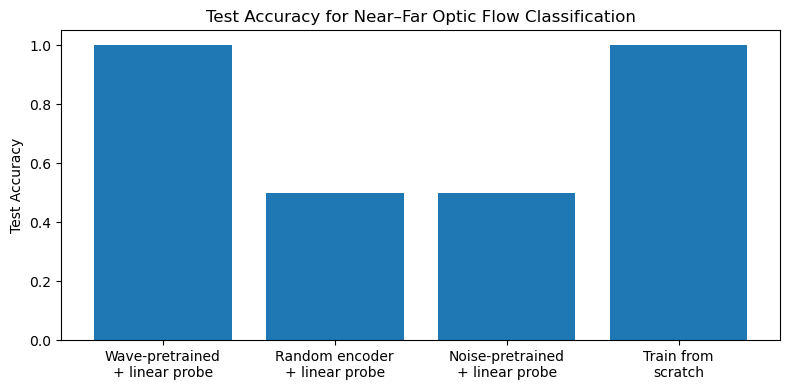

In [70]:
final_test_accs = {
    "Wave-pretrained\n+ linear probe": wave_test_acc,
    "Random encoder\n+ linear probe": random_test_acc,
    "Noise-pretrained\n+ linear probe": noise_test_acc,
    "Train from\nscratch": scratch_test_acc,
}

plt.figure(figsize=(8,4))
plt.bar(final_test_accs.keys(), final_test_accs.values())
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy for Near–Far Optic Flow Classification")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Confusion Matrices

In [62]:
def plot_confusion(encoder, classifier, loader, device, title):
    encoder.eval()
    classifier.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = classifier(encoder(x))
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy().reshape(-1)

            all_preds.append(preds)
            all_targets.append(y.numpy().reshape(-1))

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(all_targets, all_preds):
        cm[int(t), int(p)] += 1

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

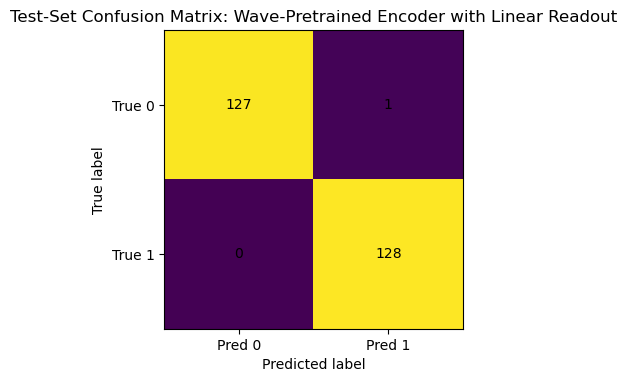

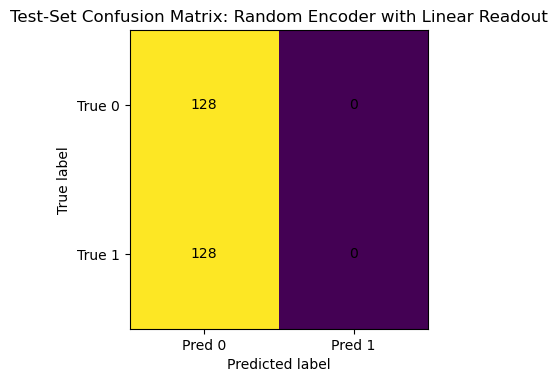

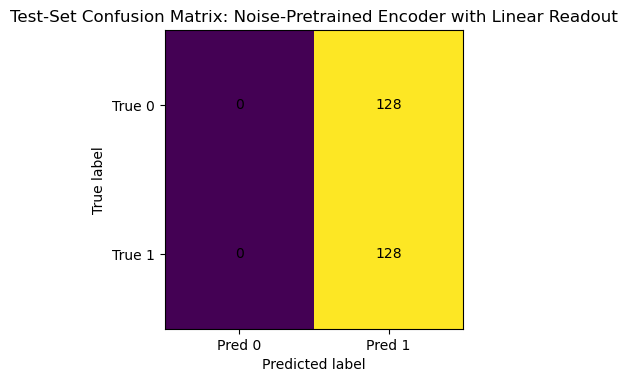

In [71]:
plot_confusion(wave_encoder, wave_classifier, test_loader, device, "Test-Set Confusion Matrix: Wave-Pretrained Encoder with Linear Readout")
plot_confusion(random_encoder, random_classifier, test_loader, device, "Test-Set Confusion Matrix: Random Encoder with Linear Readout")
plot_confusion(noise_encoder, noise_classifier, test_loader, device, "Test-Set Confusion Matrix: Noise-Pretrained Encoder with Linear Readout")